In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
replica_df = pd.read_csv("replica_ptft_curves.csv")
emp_df = pd.read_csv("emp_ptft_curves.csv")

In [5]:
emp_df_test = pd.read_csv("TESTemp_ptft_curves.csv")

In [6]:
emp_df_test_low_lr = pd.read_csv("TESTLOWLR0.05emp_ptft_curves.csv")

In [7]:
emp_df_tes_high_dim = pd.read_csv("TESTHIGHDIM15000emp_ptft_curves.csv")

In [8]:
emp_df_test_high_lr = pd.read_csv("TESTHIGHLR0.9emp_ptft_curves.csv")

In [9]:
emp_df_test_low_dim = pd.read_csv("TESTLOWDIM2000emp_ptft_curves.csv")

In [10]:
emp_df_test_high_threshold = pd.read_csv("TESTHIGHTHRESH1e-4emp_ptft_curves.csv")

In [11]:
#look at 2000 dimensions, look at 10^-4 threshold

In [12]:
emp_df_test_low_threshold = pd.read_csv("TESTLOWTHRESH1e-10emp_ptft_curves.csv")

In [6]:
emp_df.omega.value_counts()

omega
1.0    360
0.0    337
Name: count, dtype: int64

In [14]:
# --- Empirical PT+FT (standalone cell) ---
from pathlib import Path
import sys

# make repo imports work from anywhere
p = Path.cwd().resolve()
for _ in range(12):
    if (p / ".git").exists():
        sys.path.insert(0, str(p))
        break
    p = p.parent

import numpy as np
import pandas as pd
import ptft_empirical_finetune_df as emp

# alphas = np.linspace(0.01, 0.5, 1)
alphas = np.array([0.01 , 0.059, 0.108])

seeds = [0, 1, 2, 3, 4]
lmdas = [0.0]
cs = [1e-3]
omegas = [0.0]
gamma_reinits = [0.0]

df_empirical_ptft_test = emp.build_ptft_finetune_curves_dataframe(
    rho_pt=[0.10],
    rho_ft=[0.10],
    omega=omegas,
    a_pt=1.0,
    c_pt=cs,
    lambda_pt=lmdas,
    gamma_reinit=gamma_reinits,
    alphas=alphas.tolist(),
    inp_dim=5000,
    n_test=10_000,
    seeds=seeds,
    lr=0.5,
    epochs=5_000_000,
    test_every_n_epochs=5000,   # eval/stopping cadence
    log_every_n_epochs=50000,   # log cadence
    no_tuning=True,
    threshold=1e-5,
)


Starting training loop (max 5000000 epochs, threshold=1.00e-05)...
[invariants@init] c_emp: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_pos: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_neg: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00
Epoch      0 (0.0%): Train pred MSE = 8.930399e-01, Test pred MSE = 1.033539e+00, Param MSE = 1.026407e+00, Grad norm = 1.218450e-01, Beta update rate = inf, c_emp_max_dev = 3.257e-05, lam_pos_max_dev = 3.257e-05, lam_pos_neg_max_gap = 0.000e+00

Training completed at epoch 5000
Stop reason: train_pred_mse
Final Train pred MSE = 1.016313e-13
Final Test pred MSE = 1.126366e+00
Final Param MSE = 1.121147e+00
Final Grad norm = 3.275512e-08
Final Beta update rate = 2.544455e+02
Success flag: True (train_pred_mse < 1.00e-05)

Starting training loop (max 5000000 epochs, threshold=1.00e-05)...
[invariants@init] c_emp: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_pos: mean=1.019000e-01, min=2.000000e-03, ma

In [16]:
alphas = np.array([0.01 , 0.059, 0.108])

seeds = [100]
lmdas = [0.0]
cs = [1e-3]
omegas = [0.0]
gamma_reinits = [0.0]

df_empirical_ptft_test = emp.build_ptft_finetune_curves_dataframe(
    rho_pt=[0.10],
    rho_ft=[0.10],
    omega=omegas,
    a_pt=1.0,
    c_pt=cs,
    lambda_pt=lmdas,
    gamma_reinit=gamma_reinits,
    alphas=alphas.tolist(),
    inp_dim=5000,
    n_test=10_000,
    seeds=seeds,
    lr=0.5,
    epochs=5_000_000,
    test_every_n_epochs=5000,   # eval/stopping cadence
    log_every_n_epochs=50000,   # log cadence
    no_tuning=True,
    threshold=1e-5,
)


Starting training loop (max 5000000 epochs, threshold=1.00e-05)...
[invariants@init] c_emp: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_pos: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_neg: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00
Epoch      0 (0.0%): Train pred MSE = 8.329252e-01, Test pred MSE = 9.980060e-01, Param MSE = 1.016007e+00, Grad norm = 1.233192e-01, Beta update rate = inf, c_emp_max_dev = 5.802e-05, lam_pos_max_dev = 5.802e-05, lam_pos_neg_max_gap = 0.000e+00

Training completed at epoch 5000
Stop reason: train_pred_mse
Final Train pred MSE = 4.917810e-14
Final Test pred MSE = 1.079095e+00
Final Param MSE = 1.097345e+00
Final Grad norm = 2.239294e-08
Final Beta update rate = 2.326374e+02
Success flag: True (train_pred_mse < 1.00e-05)

Starting training loop (max 5000000 epochs, threshold=1.00e-05)...
[invariants@init] c_emp: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_pos: mean=1.019000e-01, min=2.000000e-03, ma

In [12]:
def std(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1)

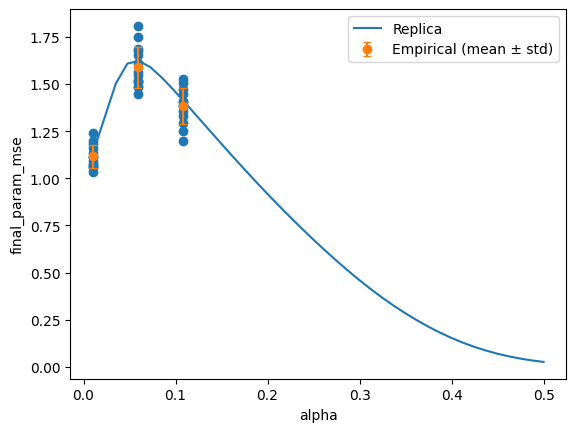

In [54]:
emp_x = "alpha"
emp_y = "final_param_mse"
group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

emp_summary = (
    emp_df_test
    .groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

emp_summary["se"] = emp_summary["std"] / np.sqrt(emp_summary["n"])

# select same slice as replica curve
mask = (
    (emp_summary.omega == 0.0) &
    (emp_summary.lambda_pt == 0.0) &
    (emp_summary.gamma_reinit == 0.0)
)

plt.figure()

# replica curve
rep_mask = (
    (replica_df.omega == 0.0) &
    (replica_df.lambda_pt == 0.0) &
    (replica_df.gamma_reinit == 0.0)
)
plt.plot(
    replica_df.loc[rep_mask, "alpha"],
    replica_df.loc[rep_mask, "mse_best"],
    label="Replica"
)

# empirical mean ± std

plt.scatter(emp_df_test.alpha, emp_df_test.final_param_mse)
plt.errorbar(
    emp_summary.loc[mask, "alpha"],
    emp_summary.loc[mask, "mean"],
    yerr=emp_summary.loc[mask, "std"],
    fmt="o",
    capsize=3,
    label="Empirical (mean ± std)"
)

plt.xlabel("alpha")
plt.ylabel("final_param_mse")
plt.legend()
plt.show()

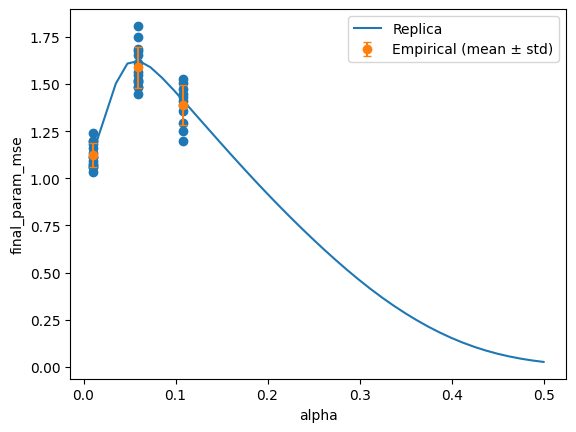

In [55]:
emp_x = "alpha"
emp_y = "final_param_mse"
group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

emp_summary = (
    emp_df_test_low_lr
    .groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

emp_summary["se"] = emp_summary["std"] / np.sqrt(emp_summary["n"])

# select same slice as replica curve
mask = (
    (emp_summary.omega == 0.0) &
    (emp_summary.lambda_pt == 0.0) &
    (emp_summary.gamma_reinit == 0.0)
)

plt.figure()

# replica curve
rep_mask = (
    (replica_df.omega == 0.0) &
    (replica_df.lambda_pt == 0.0) &
    (replica_df.gamma_reinit == 0.0)
)
plt.plot(
    replica_df.loc[rep_mask, "alpha"],
    replica_df.loc[rep_mask, "mse_best"],
    label="Replica"
)

# empirical mean ± std

plt.scatter(emp_df_test_low_lr.alpha, emp_df_test_low_lr.final_param_mse)
plt.errorbar(
    emp_summary.loc[mask, "alpha"],
    emp_summary.loc[mask, "mean"],
    yerr=emp_summary.loc[mask, "std"],
    fmt="o",
    capsize=3,
    label="Empirical (mean ± std)"
)

plt.xlabel("alpha")
plt.ylabel("final_param_mse")
plt.legend()
plt.show()

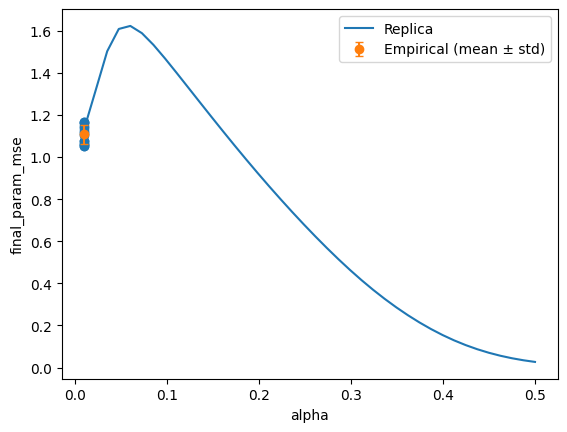

In [69]:
emp_x = "alpha"
emp_y = "final_param_mse"
group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

emp_summary = (
    emp_df_test_high_dim
    .groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

emp_summary["se"] = emp_summary["std"] / np.sqrt(emp_summary["n"])

# select same slice as replica curve
mask = (
    (emp_summary.omega == 0.0) &
    (emp_summary.lambda_pt == 0.0) &
    (emp_summary.gamma_reinit == 0.0)
)

plt.figure()

# replica curve
rep_mask = (
    (replica_df.omega == 0.0) &
    (replica_df.lambda_pt == 0.0) &
    (replica_df.gamma_reinit == 0.0)
)
plt.plot(
    replica_df.loc[rep_mask, "alpha"],
    replica_df.loc[rep_mask, "mse_best"],
    label="Replica"
)

# empirical mean ± std

plt.scatter(emp_df_test_high_dim.alpha, emp_df_test_high_dim.final_param_mse)
plt.errorbar(
    emp_summary.loc[mask, "alpha"],
    emp_summary.loc[mask, "mean"],
    yerr=emp_summary.loc[mask, "std"],
    fmt="o",
    capsize=3,
    label="Empirical (mean ± std)"
)

plt.xlabel("alpha")
plt.ylabel("final_param_mse")
plt.legend()
plt.show()

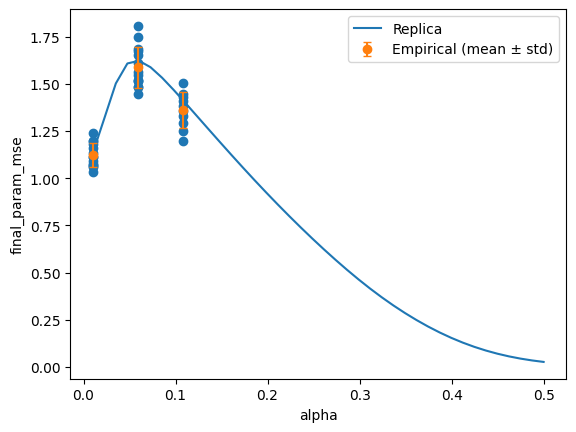

In [66]:
emp_x = "alpha"
emp_y = "final_param_mse"
group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

emp_summary = (
    emp_df_test_low_threshold
    .groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

emp_summary["se"] = emp_summary["std"] / np.sqrt(emp_summary["n"])

# select same slice as replica curve
mask = (
    (emp_summary.omega == 0.0) &
    (emp_summary.lambda_pt == 0.0) &
    (emp_summary.gamma_reinit == 0.0)
)

plt.figure()

# replica curve
rep_mask = (
    (replica_df.omega == 0.0) &
    (replica_df.lambda_pt == 0.0) &
    (replica_df.gamma_reinit == 0.0)
)
plt.plot(
    replica_df.loc[rep_mask, "alpha"],
    replica_df.loc[rep_mask, "mse_best"],
    label="Replica"
)

# empirical mean ± std

plt.scatter(emp_df_test_low_threshold.alpha, emp_df_test_low_threshold.final_param_mse)
plt.errorbar(
    emp_summary.loc[mask, "alpha"],
    emp_summary.loc[mask, "mean"],
    yerr=emp_summary.loc[mask, "std"],
    fmt="o",
    capsize=3,
    label="Empirical (mean ± std)"
)

plt.xlabel("alpha")
plt.ylabel("final_param_mse")
plt.legend()
plt.show()

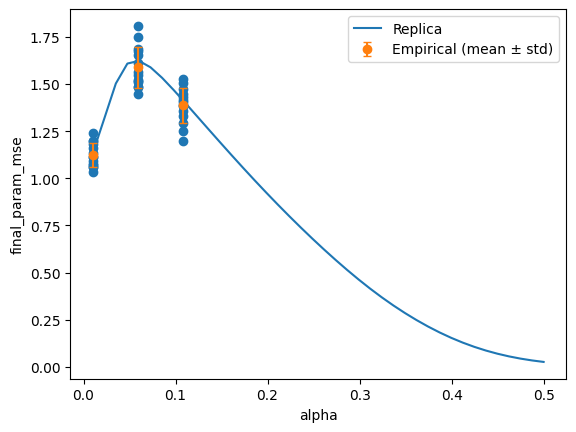

In [74]:
emp_x = "alpha"
emp_y = "final_param_mse"
group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

emp_summary = (
    emp_df_test_high_lr
    .groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

emp_summary["se"] = emp_summary["std"] / np.sqrt(emp_summary["n"])

# select same slice as replica curve
mask = (
    (emp_summary.omega == 0.0) &
    (emp_summary.lambda_pt == 0.0) &
    (emp_summary.gamma_reinit == 0.0)
)

plt.figure()

# replica curve
rep_mask = (
    (replica_df.omega == 0.0) &
    (replica_df.lambda_pt == 0.0) &
    (replica_df.gamma_reinit == 0.0)
)
plt.plot(
    replica_df.loc[rep_mask, "alpha"],
    replica_df.loc[rep_mask, "mse_best"],
    label="Replica"
)

# empirical mean ± std

plt.scatter(emp_df_test_high_lr.alpha, emp_df_test_high_lr.final_param_mse)
plt.errorbar(
    emp_summary.loc[mask, "alpha"],
    emp_summary.loc[mask, "mean"],
    yerr=emp_summary.loc[mask, "std"],
    fmt="o",
    capsize=3,
    label="Empirical (mean ± std)"
)

plt.xlabel("alpha")
plt.ylabel("final_param_mse")
plt.legend()
plt.show()

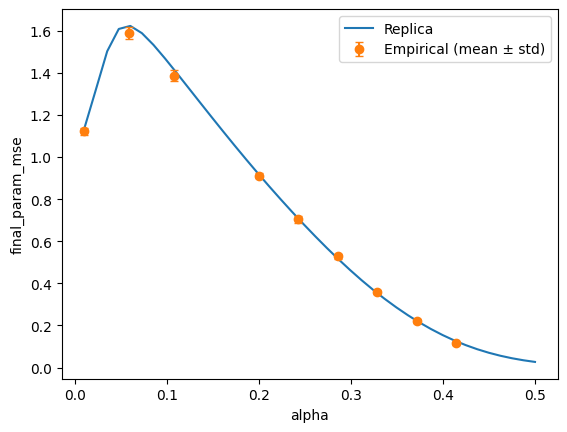

In [16]:
emp_x = "alpha"
emp_y = "final_param_mse"
group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

emp_summary = (
    emp_df_test_high_threshold
    .groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

emp_summary["se"] = emp_summary["std"] / np.sqrt(emp_summary["n"])

# select same slice as replica curve
mask = (
    (emp_summary.omega == 0.0) &
    (emp_summary.lambda_pt == 0.0) &
    (emp_summary.gamma_reinit == 0.0)
)

plt.figure()

# replica curve
rep_mask = (
    (replica_df.omega == 0.0) &
    (replica_df.lambda_pt == 0.0) &
    (replica_df.gamma_reinit == 0.0)
)
plt.plot(
    replica_df.loc[rep_mask, "alpha"],
    replica_df.loc[rep_mask, "mse_best"],
    label="Replica"
)

# empirical mean ± std

# plt.scatter(emp_df_test_high_threshold.alpha, emp_df_test_high_threshold.final_param_mse)
plt.errorbar(
    emp_summary.loc[mask, "alpha"],
    emp_summary.loc[mask, "mean"],
    yerr=emp_summary.loc[mask, "se"],
    fmt="o",
    capsize=3,
    label="Empirical (mean ± std)"
)

plt.xlabel("alpha")
plt.ylabel("final_param_mse")
plt.legend()
plt.show()

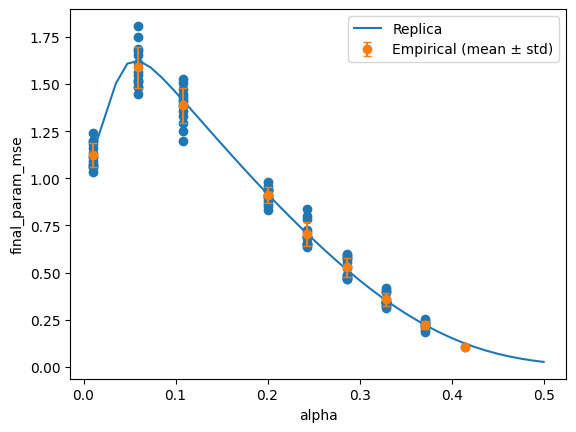

In [14]:
emp_x = "alpha"
emp_y = "final_param_mse"
group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

emp_summary = (
    emp_df_test_high_lr
    .groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

emp_summary["se"] = emp_summary["std"] / np.sqrt(emp_summary["n"])

# select same slice as replica curve
mask = (
    (emp_summary.omega == 0.0) &
    (emp_summary.lambda_pt == 0.0) &
    (emp_summary.gamma_reinit == 0.0)
)

plt.figure()

# replica curve
rep_mask = (
    (replica_df.omega == 0.0) &
    (replica_df.lambda_pt == 0.0) &
    (replica_df.gamma_reinit == 0.0)
)
plt.plot(
    replica_df.loc[rep_mask, "alpha"],
    replica_df.loc[rep_mask, "mse_best"],
    label="Replica"
)

# empirical mean ± std

plt.scatter(emp_df_test_high_lr.alpha, emp_df_test_high_lr.final_param_mse)
plt.errorbar(
    emp_summary.loc[mask, "alpha"],
    emp_summary.loc[mask, "mean"],
    yerr=emp_summary.loc[mask, "std"],
    fmt="o",
    capsize=3,
    label="Empirical (mean ± std)"
)

plt.xlabel("alpha")
plt.ylabel("final_param_mse")
plt.legend()
plt.show()

In [4]:
alphas = np.linspace(0.01, 0.5, 11)
alphas

array([0.01 , 0.059, 0.108, 0.157, 0.206, 0.255, 0.304, 0.353, 0.402,
       0.451, 0.5  ])

In [ ]:
c = 1e-3, lmda_pt = 0.0, gamma = 0.0, w = 0.0 
c = 1e-3, lmdas = -0.99*c, gamma = 1.0, w = 1.0

In [8]:
def std(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1)

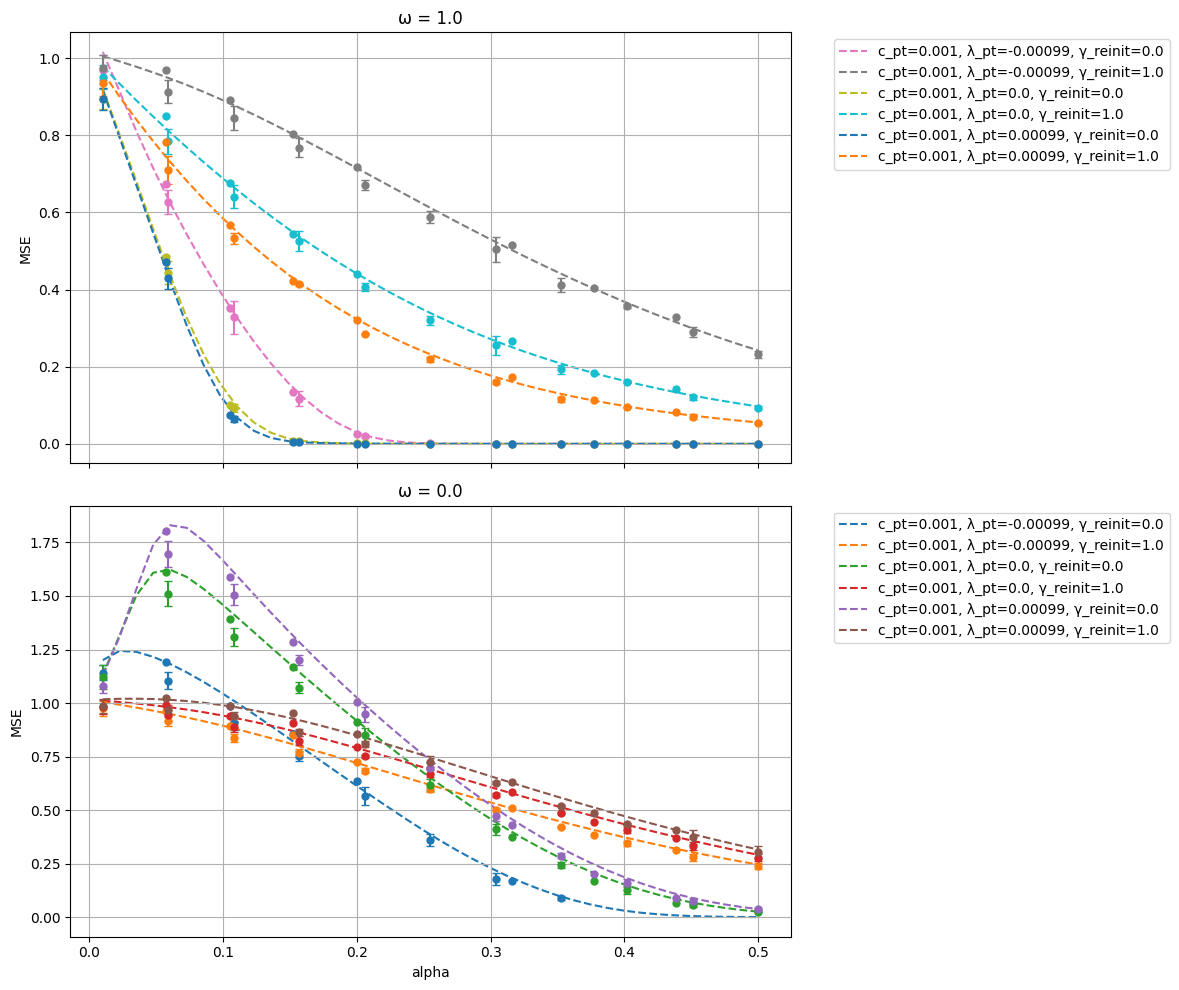

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Config ----------------
curve_df = replica_df.copy()

curve_x = "alpha"
curve_y = "mse_best"

emp_x = "alpha"
emp_y = "final_param_mse"

group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

# ---------------- Helpers ----------------
def se(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))

# ---------------- Color mapping (per setup) ----------------
all_setups = sorted(
    set(map(tuple, curve_df[group_cols].drop_duplicates().to_numpy()))
)

cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
setup_to_color = {
    setup: cycle[i % len(cycle)]
    for i, setup in enumerate(all_setups)
}


emp_summary = (
    emp_df.groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", std=std)
    .reset_index()
)


# ---------------- Plot ----------------
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ax, omega_val in zip(axes, [1.0, 0.0]):

    # ---- Curves ----
    for setup, g in curve_df[curve_df["omega"] == omega_val].groupby(group_cols):
        g = g.sort_values(curve_x)
        ax.plot(
            g[curve_x],
            g[curve_y],
            linestyle="--",
            color=setup_to_color[setup],
            label=f"c_pt={setup[1]}, λ_pt={setup[2]}, γ_reinit={setup[3]}",
            zorder=1,
        )
    
    for setup, g in emp_summary[emp_summary["omega"] == omega_val].groupby(group_cols):
        g = g.sort_values(emp_x)
        ax.errorbar(
            g[emp_x],
            g["mean"],
            yerr=g["std"],
            fmt="o",
            linestyle="none",
            color=setup_to_color[setup],
            capsize=3,
            markersize=5,
            zorder=3,
        )

    ax.set_title(f"ω = {omega_val}")
    ax.set_ylabel("MSE")
    ax.grid(True)

    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

axes[-1].set_xlabel("alpha")

fig.tight_layout()
plt.show()

In [ ]:
c = 1e-3, lmda_pt = 0.0, gamma = 0.0, w = 0.0 
c = 1e-3, lmdas = -0.99*c, gamma = 1.0, w = 1.0

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (2677563825.py, line 1)

In [92]:
emp_df.columns

Index(['status', 'setting', 'seed', 'inp_dim', 'alpha_requested', 'n_train',
       'alpha', 'n_test', 'c_pt', 'lambda_pt', 'gamma_reinit', 'rho_pt',
       'a_pt', 'rho_ft', 'omega', 'ft_teacher_norm', 'save_folder', 'lr',
       'epochs', 'test_every_n_epochs', 'log_every_n_epochs', 'no_tuning',
       'threshold', 'stop_pred_mse', 'stop_beta_rate', 'stop_grad_norm',
       'lr_decay', 'lr_decay_interval', 'stop_reason', 'final_epoch',
       'final_test_pred_mse', 'final_param_mse', 'final_grad_norm',
       'final_beta_update_rate', 'final_beta_l1', 'final_beta_l2',
       'final_active_frac', 'beta0_l2', 'empirical_omega', 'n_ov', 'n_new',
       'n_ptonly', 'n_none', 'wall_s'],
      dtype='object')

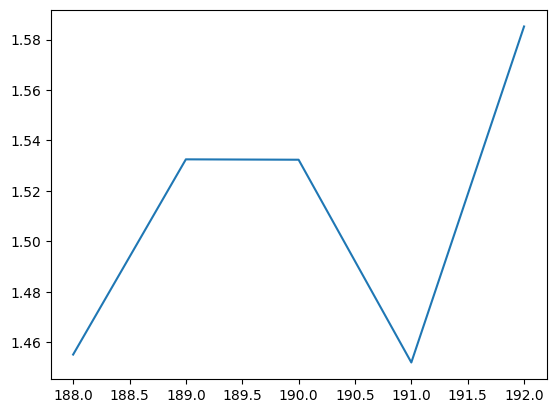

In [96]:
plt.plot(
    emp_df[
        (emp_df.alpha == 0.059) &
        (emp_df.lambda_pt == 0.0) & 
        (emp_df.gamma_reinit == 0.0) & 
        (emp_df.omega == 0.0)
    ].final_param_mse
)

In [101]:
emp_df.seed.value_counts()

seed
0    115
1     77
2     70
3     60
4     59
5     57
Name: count, dtype: int64

In [104]:
emp_df[emp_df.seed == 0].alpha.value_counts()

alpha
0.0100    12
0.0576    12
0.1050    12
0.1526    12
0.2000    12
0.2550    12
0.3162    12
0.3776    11
0.4388    11
0.5000     9
Name: count, dtype: int64

In [112]:
emp_df[
        (emp_df.alpha == 0.0576) &
        (emp_df.lambda_pt == 0.0) & 
        (emp_df.gamma_reinit == 0.0) & 
        (emp_df.omega == 0.0)].final_param_mse

192    1.613617
Name: final_param_mse, dtype: float64

In [110]:
emp_df[
        (emp_df.alpha == 0.059) &
        (emp_df.lambda_pt == 0.0) & 
        (emp_df.gamma_reinit == 0.0)
    ].final_param_mse

193    1.455085
194    1.532491
195    1.532340
196    1.451944
197    1.585176
442    0.414825
443    0.471445
444    0.464945
445    0.407437
446    0.460153
Name: final_param_mse, dtype: float64